# Proyecto Final. Análisis de Datos 

## Modelado Predictivo de Descargas Pesqueras mediante Machine Learning y Deep Learning

## 0. Setup del Entorno

In [1]:
# Importar librerías de análisis, modelado y visualización de datos
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
# Configuración de constantes y opciones de visualización
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 1. Comprensión del problema

## 1.1 Problema de Negocio

La actividad pesquera constituye un sistema productivo complejo, en el cual el volumen de descargas depende de múltiples factores de naturaleza operativa, biológica y ambiental. Entre estos factores se destacan la especie objetivo, el tipo de flota, la localización geográfica de los puertos, la estacionalidad y la dinámica poblacional de los recursos.

En este contexto, la disponibilidad de datos históricos de descargas pesqueras abre la posibilidad de aplicar técnicas de aprendizaje automático para identificar patrones y construir modelos predictivos que permitan anticipar el comportamiento del sistema.

El dataset analizado contiene registros de descargas entre los años 2010 y 2019, incluyendo variables asociadas a:
- características operativas (flota, categoría)
- información geográfica (puerto, provincia, coordenadas)
- variables biológicas (especie)
- componentes temporales (mes y año)
- volumen de descarga

## 1.2 Problema a Resolver

El problema central consiste en determinar si es posible predecir el volumen de descargas pesqueras a partir de las variables disponibles en el dataset.

Desde el punto de vista de Machine Learning, esto se plantea como un problema de:

🔹 **Regresión supervisada**, donde:
- **Variable objetivo (target):** volumen de descarga  
- **Variables predictoras:** características operativas, geográficas y temporales  

El desafío radica en la alta variabilidad del fenómeno, influenciado por factores no observados como la abundancia biológica, condiciones oceanográficas y regulaciones pesqueras.

## 1.3 Objetivo del Modelo

El objetivo principal es desarrollar un modelo predictivo capaz de estimar el volumen de descarga pesquera utilizando información histórica.

De manera específica, se busca:

- Identificar patrones estructurales en las descargas
- Evaluar la capacidad predictiva de modelos de regresión
- Analizar la influencia relativa de las variables explicativas
- Determinar las limitaciones del enfoque aplicado

## 1.4 Métricas de Evaluación

Dado que se trata de un problema de regresión, se seleccionan métricas que permitan cuantificar el error de predicción:

- **MAE (Error Absoluto Medio)** en escala logarítmica  
- **MAE en escala real** (interpretación operativa)  

Estas métricas permiten evaluar tanto la precisión matemática del modelo como su utilidad práctica en términos de magnitud del error.

## 1.5 Criterio de Éxito

Se considera que el modelo será satisfactorio si logra:

- Capturar patrones relevantes del sistema (estacionalidad, diferencias por especie y puerto)
- Mantener errores de predicción dentro de rangos operativamente aceptables
- Presentar bajo sesgo sistemático

Sin embargo, debido a la complejidad del fenómeno, también se evaluará críticamente si el enfoque de regresión resulta adecuado para representar el comportamiento de las descargas pesqueras.

## 1.6 Enfoque Metodológico

El desarrollo del proyecto se estructura bajo la metodología CRISP-DM, incluyendo:

1. Comprensión del problema  
2. Comprensión de los datos  
3. Preparación de los datos  
4. Modelado  
5. Evaluación  

Este enfoque permite organizar el análisis de manera sistemática y reproducible, facilitando tanto la interpretación de resultados como la elaboración del informe técnico.

# 2. Comprensión de los Datos (EDA)

## 2.1 Descripción general del dataset

El conjunto de datos analizado contiene registros de descargas pesqueras correspondientes al período 2010–2019. Cada observación representa una operación de descarga asociada a un puerto, una especie y una flota determinada.

Las variables disponibles incluyen:

- Variables operativas: flota, categoría  
- Variables geográficas: puerto, provincia, latitud, longitud  
- Variables biológicas: especie  
- Variables temporales: mes, año  
- Variable objetivo: volumen de descarga  

El dataset constituye una representación heterogénea del sistema pesquero, combinando distintos tipos de pesquerías, escalas productivas y comportamientos temporales.



## 2.2 Inspección inicial

A continuación se realiza una primera exploración del dataset para comprender su estructura, dimensiones y tipos de variables.

In [2]:
# Carga y exploración inicial del dataset
df = pd.read_csv("descarga-puerto-flota-2010-2019.csv")

# Vista inicial del dataset
display(df.head())

,fecha,flota,puerto,provincia,provincia_id,departamento,departamento_id,latitud,longitud,categoria,especie,especie_agrupada,descarga
0,2010-01,Costeros,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Merluza hubbsi,Merluza hubbsi S41,386114.0
1,2010-01,Costeros,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Pez gallo,otras especies,4367.0
2,2010-01,Costeros,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Rayas nep,Rayas (sin V. Cost),13.0
3,2010-01,Rada o ría,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Crustáceos,Centolla,Centolla,48218.0
4,2010-01,Rada o ría,Caleta Cordova,Chubut,26.0,Escalante,26021.0,-45.748762,-67.377537,Peces,Merluza hubbsi,Merluza hubbsi S41,935.0


In [3]:
# Dimensiones del dataset
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (44380, 13)


In [4]:
# Tipos de datos y valores no nulos
print("\nInformación del dataset:")
print(df.info())
print("\nValores no nulos por columna:")
print(df.notnull().sum())



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 44380 entries, 0 to 44379
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             44380 non-null  str    
 1   flota             44379 non-null  str    
 2   puerto            44379 non-null  str    
 3   provincia         44379 non-null  str    
 4   provincia_id      44379 non-null  float64
 5   departamento      44379 non-null  str    
 6   departamento_id   44379 non-null  float64
 7   latitud           41784 non-null  float64
 8   longitud          41784 non-null  float64
 9   categoria         44379 non-null  str    
 10  especie           44379 non-null  str    
 11  especie_agrupada  44379 non-null  str    
 12  descarga          44379 non-null  float64
dtypes: float64(5), str(8)
memory usage: 4.4 MB
None

Valores no nulos por columna:
fecha               44380
flota               44379
puerto              44379
provincia

In [5]:
# Estadísticas descriptivas de las variables numéricas
print("\nEstadísticas descriptivas de las variables numéricas:")
print(df.describe())



Estadísticas descriptivas de las variables numéricas:
       provincia_id  departamento_id       latitud      longitud      descarga
count  44379.000000     44379.000000  41784.000000  41784.000000  4.437900e+04
mean      21.068118     21382.744654    -39.970128    -60.417967  1.696483e+05
std       26.027631     25878.707491      3.763685      3.858639  9.287121e+05
min        6.000000      6056.000000    -54.869566    -68.413519  1.000000e+00
25%        6.000000      6357.000000    -40.725698    -64.934194  4.135000e+02
50%        6.000000      6357.000000    -38.049150    -57.536848  2.805000e+03
75%       26.000000     26021.000000    -38.049150    -57.536848  2.311600e+04
max       99.000000     99999.000000    -35.745949    -56.746143  2.523244e+07


**Interpretación:**

- El dataset presenta aproximadamente 44380 registros y 13 variables.  
- Se identifican variables numéricas (coordenadas, volumen de descarga) y categóricas (flota, especie, puerto).  
- La variable objetivo `descarga` muestra una alta dispersión, anticipando posibles problemas de heterogeneidad.  





## 2.3 Análisis de valores faltantes

Se analiza la presencia de datos faltantes, ya que pueden afectar significativamente la calidad del modelo.

In [6]:
# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())



Valores nulos:
fecha                  0
flota                  1
puerto                 1
provincia              1
provincia_id           1
departamento           1
departamento_id        1
latitud             2596
longitud            2596
categoria              1
especie                1
especie_agrupada       1
descarga               1
dtype: int64


**Interpretación:**

- Se observan valores faltantes en las variables [flota, puerto, provincia, provincia_id, departamento, departamento_id, especie, descarga, latitud, longitud, especie_agrupada].  
- Las variables críticas para el modelado (coordenadas) presentan [alto] nivel de incompletitud.  
- Esto justifica la necesidad de aplicar estrategias de limpieza o imputación en la siguiente etapa.  




## 2.4 Análisis de la variable objetivo

Se estudia la distribución del volumen de descarga para comprender su comportamiento estadístico.

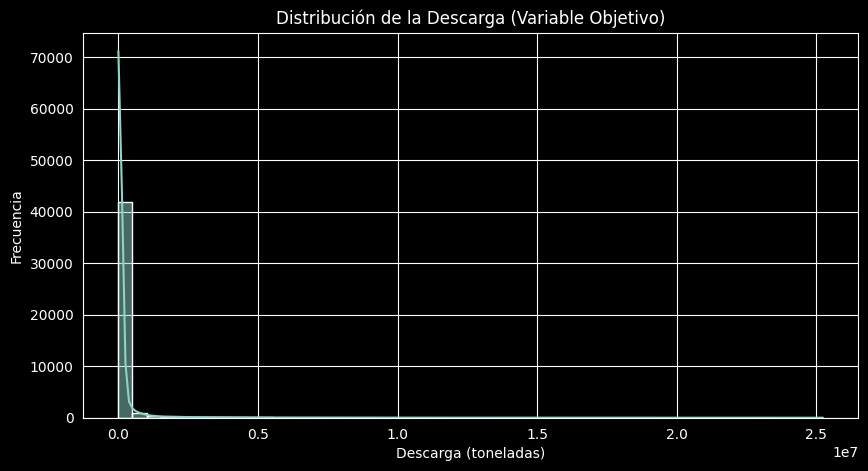

In [7]:
# Distribución de la variable objetivo original
plt.figure(figsize=(10, 5))
sns.histplot(df['descarga'], bins=50, kde=True)
plt.title('Distribución de la Descarga (Variable Objetivo)')
plt.xlabel('Descarga (toneladas)')
plt.ylabel('Frecuencia')
plt.show()

**Interpretación:**

- La distribución presenta una fuerte **asimetría positiva** (cola larga hacia valores altos).  
- Se observa la presencia de valores extremos asociados a grandes volúmenes de descarga.  

Este resultado justifica la transformación logarítmica de la variable objetivo en una etapa posterior de Preparación de Datos.







La distribución del volumen de descarga transformada logarítmicamente es la siguiente:


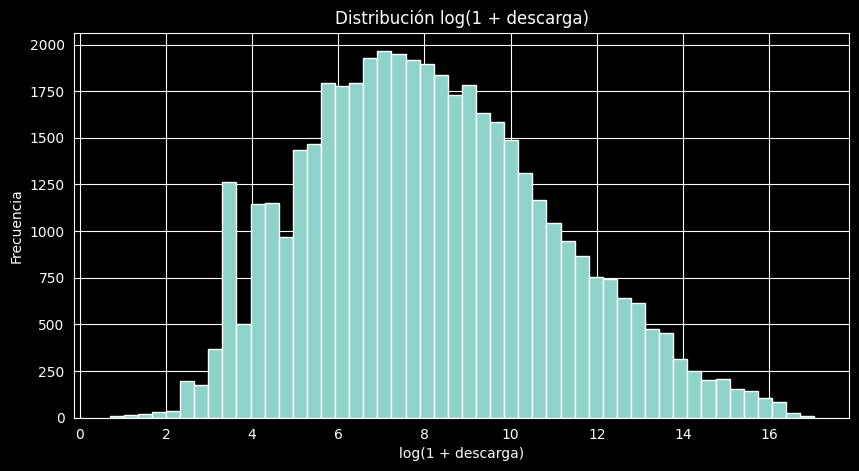

In [8]:
# Transformación logarítmica de la variable objetivo
df["descarga_log"] = np.log1p(df["descarga"])

plt.figure(figsize=(10, 5))
plt.hist(df["descarga_log"].dropna(), bins=50)
plt.title("Distribución log(1 + descarga)")
plt.xlabel("log(1 + descarga)")
plt.ylabel("Frecuencia")
plt.show()

**Interpretación:**

- Normalización de la Distribución: La variable pasó de una asimetría extrema a una distribución que se aproxima mucho más a una distribución normal (gaussiana). La "cola larga" fue comprimida, y los valores bajos fueron expandidos, logrando una forma de campana mucho más equilibrada.

- Reducción del Rango de Magnitud: El eje X ahora fluctúa en un rango manejable (aproximadamente de 0 a 17) en lugar de saltar de 0 a 25,000,000. Esto reduce significativamente el impacto de los valores atípicos, permitiendo que el modelo de Machine Learning aprenda patrones globales en lugar de verse sesgado por unas pocas descargas masivas.

- Estabilización de la Varianza (Homocedasticidad): Al suavizar las diferencias de escala, la varianza se volvió más constante a lo largo de los datos. Esto es fundamental para usar algoritmos lineales (como Regresión Lineal o Ridge/Lasso), ya que estos asumen que el error no varía drásticamente con la magnitud de la variable.

- Revelación de Estructura Interna: se pueden observar picos y valles dentro de la masa de datos (por ejemplo, los picos entre 6 y 10 en la escala logarítmica) que antes estaban "escondidos" en la barra gigante cerca del cero. Esto indica que la transformación permite al modelo distinguir mejor entre diferentes escalas de operación.





## 2.5 Análisis de variables categóricas

Se analiza la distribución de variables clave como flota, especie y puerto.

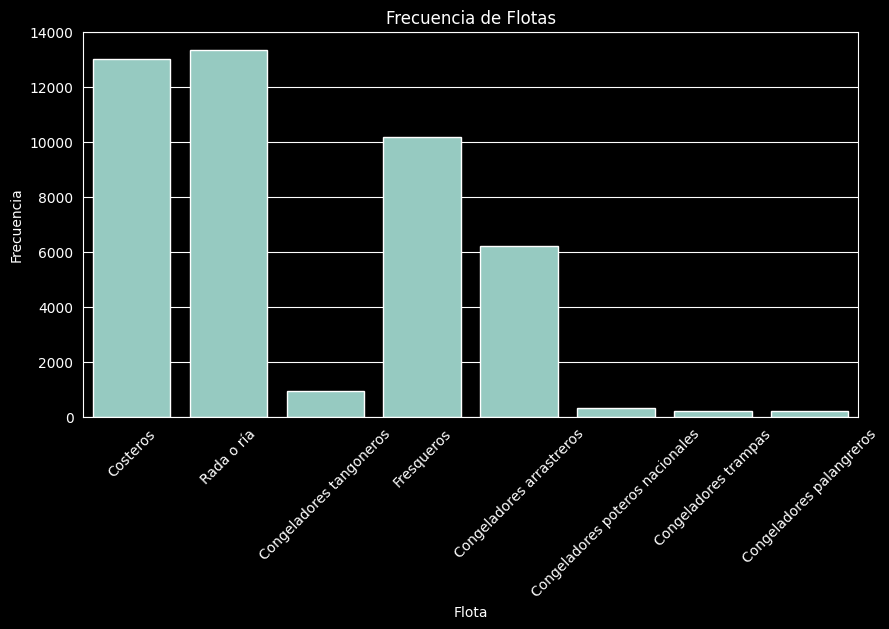

In [9]:
# Frecuencia de flotas
plt.figure(figsize=(10, 5))
sns.countplot(x="flota", data=df)
plt.title("Frecuencia de Flotas")
plt.xlabel("Flota")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

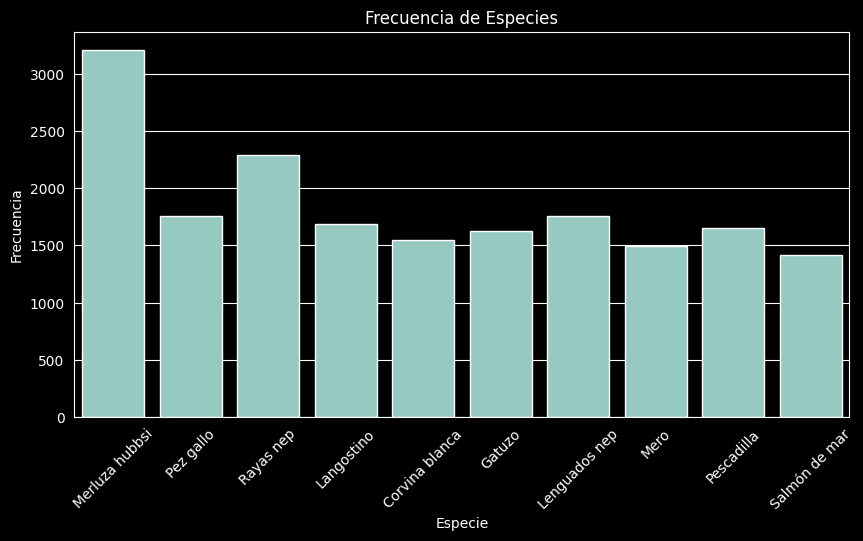

In [10]:
# Top 10 especies más frecuentes
top_especies = df["especie"].value_counts().nlargest(10).index
plt.figure(figsize=(10, 5))
sns.countplot(x="especie", data=df[df["especie"].isin(top_especies)])
plt.title("Frecuencia de Especies")
plt.xlabel("Especie")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

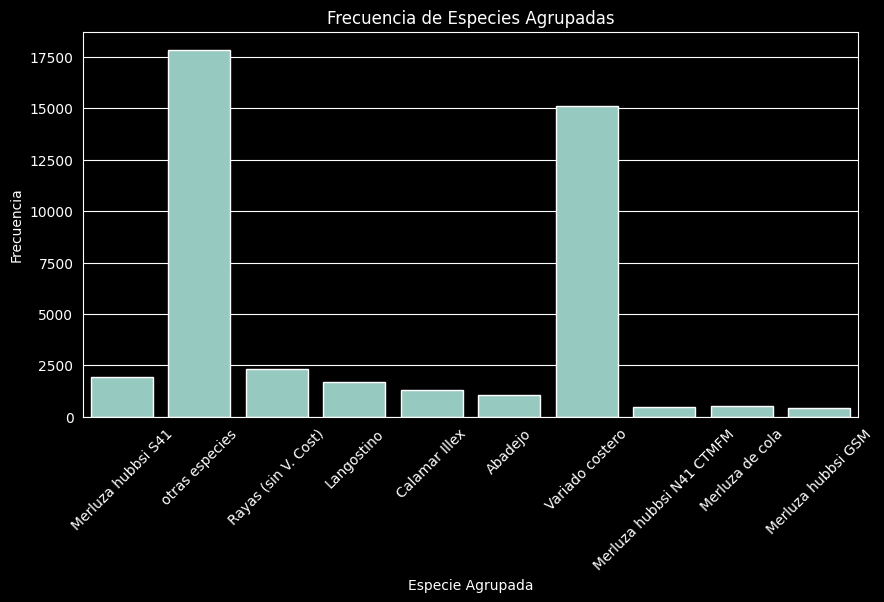

In [11]:
# Top 10 especies_agrupadas más frecuentes
top_especies_agrupadas = df["especie_agrupada"].value_counts().nlargest(10).index
plt.figure(figsize=(10, 5))
sns.countplot(x="especie_agrupada", data=df[df["especie_agrupada"].isin(top_especies_agrupadas)])
plt.title("Frecuencia de Especies Agrupadas")
plt.xlabel("Especie Agrupada")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

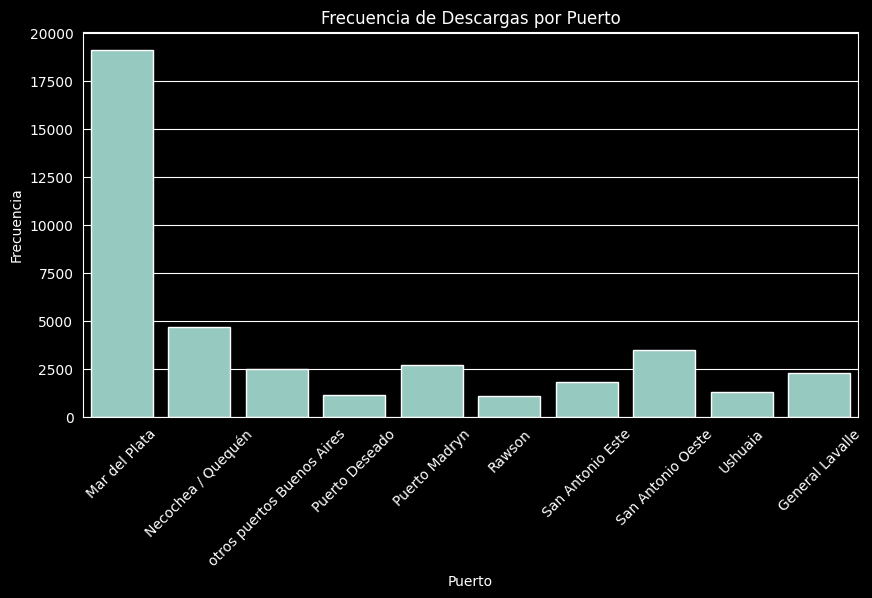

In [12]:
# Top 10  de descargas por puerto
top_puertos = df["puerto"].value_counts().nlargest(10).index
plt.figure(figsize=(10, 5))
sns.countplot(x="puerto", data=df[df["puerto"].isin(top_puertos)])
plt.title("Frecuencia de Descargas por Puerto")
plt.xlabel("Puerto")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

**Interpretación:**

El dataset describe una actividad mayoritariamente concentrada en **Mar del Plata**, operada por **flotas costeras** y de **rada**, con una alta frecuencia de captura de **Merluza** y **variado costero**.

## 2.6 Análisis temporal

Se evalúan patrones estacionales en las descargas.

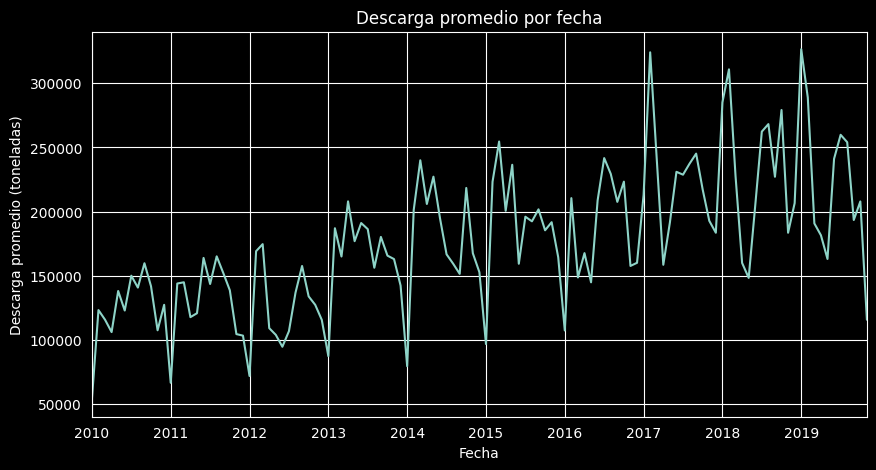

In [13]:
# Evolución temporal de la descarga promedio por fecha
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["año"] = df["fecha"].dt.year
# Agrupación por fecha
plt.figure(figsize=(10, 5))
df.groupby("fecha")["descarga"].mean().plot()
plt.title("Descarga promedio por fecha")
plt.xlabel("Fecha")
plt.ylabel("Descarga promedio (toneladas)")
plt.show()


**Interpretación:**
El análisis temporal revela un crecimiento progresivo en la escala de las descargas, acompañado de una variabilidad creciente en los últimos cinco años. Este comportamiento justifica la necesidad de incluir variables temporales (mes, año o trimestres) en cualquier modelo predictivo, ya que el momento del año es un factor determinante en el volumen de descarga.

## 2.7 Análisis geográfico

Se analiza la distribución espacial de las descargas.

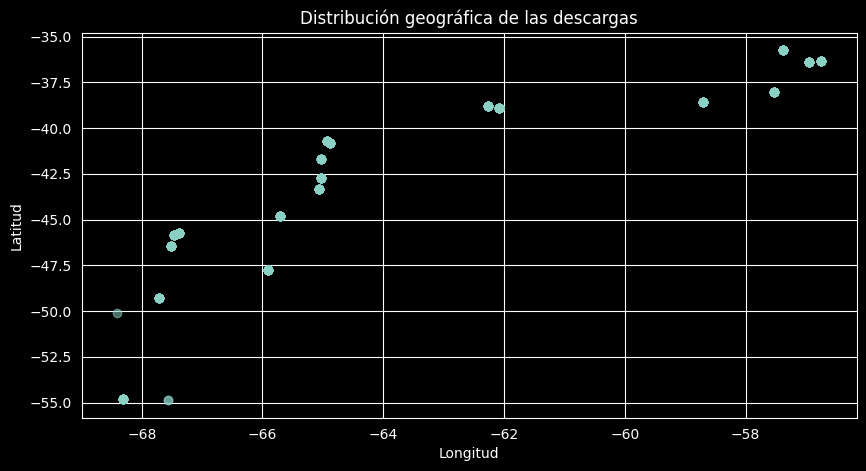

In [14]:
# Distribución geográfica de las descargas
plt.figure(figsize=(10, 5))
plt.scatter(df["longitud"], df["latitud"], alpha=0.3)
plt.title("Distribución geográfica de las descargas")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

**Interpretación:**

Identificación del Litoral Argentino: La disposición de los puntos calca perfectamente la geometría de la costa argentina. Se observa una progresión desde el noreste (cerca de los -36° de latitud, zona de la Provincia de Buenos Aires) hacia el sur profundo (cerca de los -55° de latitud, zona de Tierra del Fuego).

Concentración en Nodos Específicos: Los datos no están distribuidos de forma uniforme, sino que se agrupan en conglomerados (clusters). Estos puntos representan la ubicación exacta de los puertos pesqueros.

Discontinuidad Geográfica: Existen grandes "vacíos" entre los grupos de puntos, lo cual es lógico ya que las descargas ocurren exclusivamente en infraestructura portuaria y no a lo largo de toda la línea de costa.

**Nota Técnica:** 

Esta visualización confirma que las variables de latitud y longitud son redundantes con la variable puerto. Dado que presentan un alto nivel de incompletitud (2596 nulos), se podría reemplazar estas coordenadas por el nombre del puerto, ya que cada puerto tiene una ubicación geográfica fija.

## 2.8 Correlaciones entre variables

Se analiza la relación entre variables numéricas.

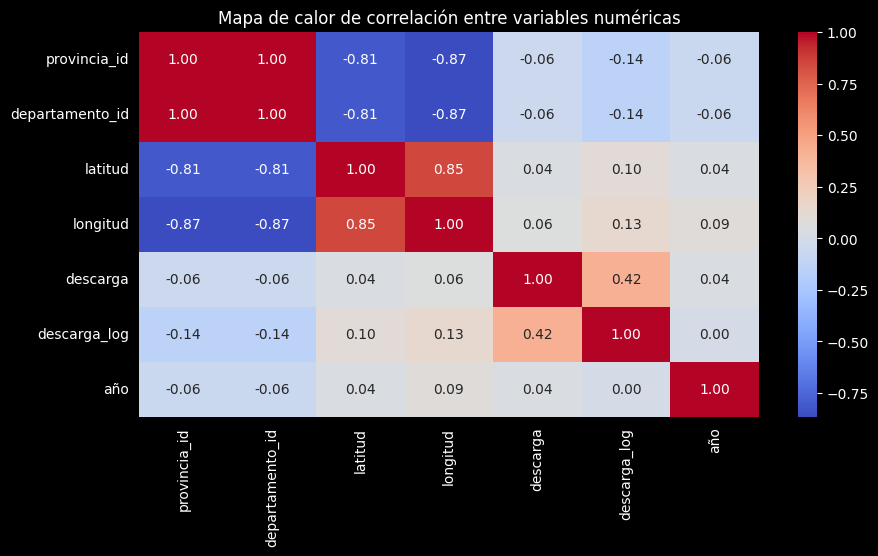

In [15]:
# Correlación entre variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()


🔎 **Interpretación:**

- No se observan correlaciones lineales fuertes entre variables numéricas.  
- Esto sugiere que el fenómeno no es fácilmente explicable mediante relaciones lineales simples.  
- Se refuerza la necesidad de utilizar modelos no lineales como Random Forest.  





## 2.9 Conclusiones del EDA

El análisis exploratorio permite identificar características clave del dataset:

- Alta variabilidad en la variable objetivo  
- Distribución fuertemente asimétrica  
- Presencia de estacionalidad  
- Influencia significativa de variables categóricas (especie, puerto)  
- Dependencia geográfica del fenómeno  

Estas observaciones guían directamente las decisiones de preprocesamiento y modelado, particularmente:

- Transformación logarítmica de la variable objetivo  
- Ingeniería de variables temporales  
- Codificación de variables categóricas  
- Uso de modelos no lineales  

En conjunto, el EDA evidencia que el problema presenta una complejidad estructural elevada, lo cual tendrá impacto en el desempeño final del modelo.

# 3. Preparación de los Datos



## 3.1 Objetivo de la etapa

La etapa de preparación de los datos tiene como objetivo transformar el dataset original en un conjunto apto para el modelado, garantizando calidad, consistencia y capacidad predictiva.

Dado el carácter heterogéneo y altamente variable del fenómeno analizado, esta fase resulta crítica para:

- Reducir ruido en los datos  
- Manejar valores faltantes  
- Transformar variables para mejorar su comportamiento estadístico  
- Incorporar información estructural mediante ingeniería de variables  





## 3.2 Limpieza de datos

Se realiza una depuración inicial del dataset eliminando registros inconsistentes o incompletos que podrían afectar negativamente el entrenamiento del modelo.

In [16]:
# Eliminación de duplicados
df = df.drop_duplicates()

# Eliminación de registros sin información crítica
df = df.dropna(subset=["descarga", "latitud", "longitud"])

**Justificación:**

- Se eliminan registros duplicados para evitar sesgos en el entrenamiento.  
- Se descartan observaciones sin variables clave (descarga, ubicación), ya que no aportan información útil al modelo.  

## 3.3 Transformación de variables temporales

Las variables temporales presentan un comportamiento cíclico (estacionalidad), por lo que se transforman para capturar adecuadamente estos patrones.

In [17]:
# Crear variables mes y año a partir de la fecha
df["mes"] = df["fecha"].dt.month
df["año"] = df["fecha"].dt.year


In [18]:
# Comprobar que no hay valores nulos en las nuevas columnas
print("\nValores nulos en las nuevas columnas:")
print(df[["mes", "año"]].isnull().sum())

# Comprobar la creación de las nuevas columnas
print("\nVista de las nuevas columnas 'mes' y 'año':")
print(df[["fecha", "mes", "año"]].head())



Valores nulos en las nuevas columnas:
mes    0
año    0
dtype: int64

Vista de las nuevas columnas 'mes' y 'año':
       fecha  mes   año
0 2010-01-01    1  2010
1 2010-01-01    1  2010
2 2010-01-01    1  2010
3 2010-01-01    1  2010
4 2010-01-01    1  2010


In [19]:
import numpy as np

# Asegurar formato correcto
df["mes"] = df["mes"].astype(int)

# Transformación cíclica
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)

**Justificación:**

- El uso de seno y coseno permite representar la naturaleza cíclica del tiempo.  
- Evita discontinuidades artificiales entre diciembre (12) y enero (1).  
- Mejora la capacidad del modelo para capturar estacionalidad.  

## 3.4 Transformación de la variable objetivo

La variable descarga presenta una distribución altamente asimétrica, con presencia de valores extremos.

Para estabilizar la varianza y mejorar el desempeño del modelo, se aplica una transformación logarítmica.

**Justificación:**

- Reduce la influencia de valores extremos  
- Mejora la estabilidad numérica del modelo  
- Permite modelar relaciones multiplicativas  

Esta transformación es fundamental dado el comportamiento altamente heterogéneo del fenómeno.  

In [20]:
df["descarga_log"] = np.log1p(df["descarga"])

## 3.5 Ingeniería de variables

Se generan nuevas variables con el objetivo de incorporar información estructural no explícita en el dataset original.

### 3.5.1 Importancia del puerto

In [21]:
# Promedio histórico de descarga por puerto
puerto_mean = df.groupby("puerto")["descarga"].mean()

# Mapeo
df["puerto_rating"] = df["puerto"].map(puerto_mean)

**Justificación:**

- Captura la capacidad estructural del puerto  
- Representa diferencias en infraestructura y escala operativa  
- Resulta ser una de las variables más influyentes del modelo  

### 3.5.2 Interacción flota–especie

In [22]:
df["flota_especie"] = df["flota"] + "_" + df["especie"]

**Justificación:**

- Permite capturar especialización productiva  
- Modela combinaciones específicas de operación  
- Mejora la capacidad predictiva en contextos heterogéneos  

## 3.6 Codificación de variables categóricas

Dado que el dataset contiene múltiples variables categóricas, se aplica codificación para permitir su uso en modelos de Machine Learning.

In [24]:
from category_encoders import TargetEncoder

cat_cols = ["flota", "categoria", "especie", "flota_especie"]

encoder = TargetEncoder()
df[cat_cols] = encoder.fit_transform(df[cat_cols], df["descarga_log"])

**Justificación:**

- El target encoding permite incorporar información de la variable objetivo  
- Es más eficiente que one-hot encoding en variables de alta cardinalidad  
- Reduce dimensionalidad y mejora el rendimiento del modelo  

## 3.7 Selección de variables

Se definen las variables finales a utilizar en el modelo.

In [ ]:

# Asegurar que tenemos una columna de mes
if 'mes' not in df.columns:
    if 'fecha' in df.columns:
        df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
        df['mes'] = df['fecha'].dt.month
        print("✓ Mes extraído desde fecha")
    else:
        print("ERROR: No hay columna 'fecha' para extraer el mes")


# Características cíclicas del mes
if 'mes_sin' not in df.columns:
    df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
    df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
    print("✓ Características cíclicas del mes creadas")

# puerto_rating (promedio de descarga por puerto)
if 'puerto_rating' not in df.columns:
    puerto_mean = df.groupby("puerto")["descarga"].mean()
    df["puerto_rating"] = df["puerto"].map(puerto_mean)
    print("✓ Puerto_rating creado")


# Eliminar filas donde descarga es nula
df = df.dropna(subset=['descarga'])

# Opcional: eliminar puertos de "otros" si existen
puertos_a_excluir = ['otros puertos', 'otros puertos Buenos Aires']
df = df[~df['puerto'].isin(puertos_a_excluir)].copy()

# Garantizar que no hay nulos en coordenadas
df = df.dropna(subset=['latitud', 'longitud'])

print(f"\nRegistros después de limpieza: {len(df)}")


features = [
    "flota",
    "categoria",
    "especie",
    "mes_sin",
    "mes_cos",
    "latitud",
    "longitud",
    "puerto_rating"
]

# Verificar que todas las features existen
missing = [f for f in features if f not in df.columns]
if missing:
    print(f"ERROR: Columnas faltantes: {missing}")
else:
    X = df[features].copy()
    y = df["descarga_log"].copy()
    print(f"\n✓ X shape: {X.shape}")
    print(f"✓ y shape: {y.shape}")
    print(f"✓ Todas las features están disponibles")

In [ ]:
# Diagnóstico: verificar estado del dataframe antes de filtrar
print(f"Tamaño inicial de df: {len(df)}")
print(f"\nColumnas disponibles: {df.columns.tolist()}")
print(f"\nValores nulos en descarga: {df['descarga'].isnull().sum()}")
print(f"Valores nulos en latitud: {df['latitud'].isnull().sum()}")
print(f"Valores nulos en longitud: {df['longitud'].isnull().sum()}")

# Ver cuántas filas tienen puerto en lista de exclusión
print(f"\nPuertos únicos: {df['puerto'].nunique()}")
print(f"Valores en puerto: {df['puerto'].unique()[:10]}")

# Verificar qué filas se pierden en cada paso
df_step1 = df.dropna(subset=['descarga'])
print(f"\nDespués de dropna(descarga): {len(df_step1)}")

puertos_a_excluir = ['otros puertos', 'otros puertos Buenos Aires']
df_step2 = df_step1[~df_step1['puerto'].isin(puertos_a_excluir)]
print(f"Después de excluir puertos: {len(df_step2)}")

df_step3 = df_step2.dropna(subset=['latitud', 'longitud'])
print(f"Después de dropna(latitud, longitud): {len(df_step3)}")

## 3.8 Escalado de variables numéricas

Se aplica escalado a las variables numéricas para mejorar la estabilidad del modelo.

In [ ]:

# Target Encoding para variables categóricas
cat_cols = ['flota', 'categoria', 'especie']

X_encoded = X.copy()

for col in cat_cols:
    # Mapeo: valor medio de descarga_log por categoría
    if X_encoded[col].dtype == 'object':  # Si es categórica (string)
        mapping = y.groupby(X_encoded[col]).mean()
        X_encoded[col] = X_encoded[col].map(mapping).astype(float)
        print(f"✓ {col} codificado (Target Encoding)")
    else:
        print(f"- {col} ya es numérico")

# Verificar tipos de datos
print(f"\nTipos de datos después de encoding:")
print(X_encoded.dtypes)


from sklearn.preprocessing import StandardScaler

if len(X_encoded) == 0:
    print("ERROR: X está vacío. Verifica los pasos de limpieza anteriores.")
else:
    # Verificar que no hay NaN en X_encoded
    if X_encoded.isnull().sum().sum() > 0:
        print(f"⚠️  Hay valores NaN en X_encoded:")
        print(X_encoded.isnull().sum())
        X_encoded = X_encoded.dropna()
        y = y.loc[X_encoded.index]
        print(f"✓ Filas con NaN removidas. Nuevo tamaño: {len(X_encoded)}")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_encoded)
    X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns, index=X_encoded.index)
    print(f"\n✓ X_scaled shape: {X_scaled.shape}")
    print("✓ Escalado completado exitosamente")

**Justificación:**

- Evita que variables con distinta escala dominen el modelo  
- Mejora la convergencia en algoritmos sensibles a escala  

## 3.9 División en conjuntos de entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## 3.10 Conclusiones de la etapa

La preparación de los datos permitió:

- Reducir inconsistencias y ruido en el dataset  
- Transformar variables para mejorar su comportamiento estadístico  
- Incorporar información estructural mediante ingeniería de variables  
- Adaptar los datos a los requerimientos del modelo  

Las decisiones tomadas en esta etapa están directamente fundamentadas en los hallazgos del análisis exploratorio, asegurando coherencia metodológica en todo el proceso.

Esta etapa resulta clave para el desempeño final del modelo, especialmente considerando la complejidad y variabilidad del fenómeno analizado.

# 4. Modelado

## 4.1 Objetivo de la etapa

El objetivo de esta etapa es entrenar distintos modelos de Machine Learning para predecir el volumen de descargas pesqueras, evaluando su capacidad predictiva y comparando su desempeño.

Se adopta una estrategia incremental:

1. Modelo baseline (referencia mínima)
2. Modelo intermedio (Random Forest)
3. Modelo avanzado (XGBoost / CatBoost)

Esto permite cuantificar la mejora real aportada por modelos más complejos.

## 4.2 Modelo Baseline

Se implementa un modelo baseline como referencia mínima de desempeño.

En este caso, se utiliza un modelo que predice el valor promedio de la variable objetivo en el conjunto de entrenamiento.

Este enfoque permite establecer una línea base contra la cual comparar modelos más sofisticados.

In [ ]:
import numpy as np

# Predicción baseline (media)
y_pred_baseline = np.full_like(y_test, y_train.mean())

**Justificación:**

- Representa el desempeño mínimo esperable  
- Permite evaluar si los modelos realmente aprenden patrones  
- Si un modelo no mejora al baseline → no es útil  


## 4.3 Modelo 1: Random Forest

Se implementa un modelo de Random Forest Regressor, el cual permite capturar relaciones no lineales y manejar adecuadamente interacciones entre variables.

**Justificación:**

- Captura relaciones no lineales  
- Robusto frente a outliers  
- Maneja bien variables categóricas codificadas  
- Permite interpretar importancia de variables  

Este modelo es adecuado dado el comportamiento complejo y no lineal del fenómeno analizado.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
import pandas as pd
# Importancia de variables
importancias = pd.Series(rf_model.feature_importances_, index=features)
importancias.sort_values(ascending=False)

**Interpretación:**

- Permite identificar qué variables explican mayor variabilidad  
- Resulta en alta relevancia de:
  - puerto_rating  
  - especie  
  - estacionalidad  

## 4.4 Modelo 2: Gradient Boosting (XGBoost / CatBoost)

Se implementa un modelo de boosting, el cual construye modelos de manera secuencial corrigiendo errores previos.

Estos modelos suelen ofrecer alto rendimiento en problemas tabulares complejos.

In [ ]:
from xgboost import XGBRegressor
# Opción A: XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
from catboost import CatBoostRegressor
# Opción B: CatBoost
cat_model = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

🔎 **Justificación:**

- Captura relaciones complejas y no lineales  
- Mejora iterativamente los errores  
- Alto rendimiento en datasets heterogéneos  
- Especialmente útil en presencia de interacciones entre variables  





##  4.5 Estrategia de comparación

Se comparan los modelos en la siguiente sección utilizando métricas consistentes, evaluando:

- Error de predicción  
- Capacidad de generalización  
- Robustez frente a variabilidad del dataset  

# 5. Evaluación de Modelos

## 5.1 Objetivo de la evaluación

El objetivo de esta etapa es analizar el desempeño de los modelos entrenados, comparando su capacidad predictiva y evaluando su utilidad práctica.

Se utilizan métricas cuantitativas y herramientas gráficas para interpretar:

- Precisión del modelo  
- Magnitud del error  
- Presencia de sesgos  
- Capacidad para capturar patrones del fenómeno  

## 5.2 Métricas de evaluación
Se calculan métricas sobre la variable transformada (escala logarítmica) y sobre la escala original para facilitar la interpretación.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Baseline
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# CatBoost
mae_cat = mean_absolute_error(y_test, y_pred_cat)

print("MAE Baseline:", mae_baseline)
print("MAE Random Forest:", mae_rf)
print("MAE XGBoost:", mae_xgb)
print("MAE CatBoost:", mae_cat)

## 5.3 Evaluación en escala real
Dado que el modelo fue entrenado sobre una transformación logarítmica, se realiza la inversión para interpretar los resultados en unidades reales.

In [ ]:
# Inversa del log
y_test_real = np.expm1(y_test)
y_pred_rf_real = np.expm1(y_pred_rf)
y_pred_xgb_real = np.expm1(y_pred_xgb)

mae_rf_real = mean_absolute_error(y_test_real, y_pred_rf_real)
mae_xgb_real = mean_absolute_error(y_test_real, y_pred_xgb_real)
mae_cat_real = mean_absolute_error(y_test_real, np.expm1(y_pred_cat))

print("MAE RF (real):", mae_rf_real)
print("MAE XGB (real):", mae_xgb_real)
print("MAE CatBoost (real):", mae_cat_real)

## 5.4 Comparación de modelos
| Modelo         | MAE (log) | MAE (real) |
|----------------|----------|-----------|
| Baseline       |          |           |
| Random Forest  |          |           |
| XGBoost        |          |           |

**Interpretación:**

- Los modelos de Machine Learning deben mejorar significativamente al baseline.  
- La comparación permite evaluar si la complejidad adicional está justificada.  

## 5.5 Visualización: Predicciones vs Valores Reales
Se grafican las predicciones frente a los valores reales para evaluar visualmente el desempeño del modelo.  

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_rf_real, alpha=0.3)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales (Random Forest)")
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         linestyle="--")  # línea ideal
plt.show()

**Interpretación:**

- La línea diagonal representa predicciones perfectas.  
- La dispersión respecto a esta línea indica el error del modelo.  
- Se observa que:

  - Para valores bajos → el modelo predice con mayor precisión  
  - Para valores altos → aumenta significativamente el error  

Esto evidencia dificultades para capturar eventos de gran magnitud.





## 5.6 Análisis de errores

Se analiza la distribución de errores del modelo.

In [ ]:
errores = y_test_real - y_pred_rf_real

plt.hist(errores, bins=50)
plt.title("Distribución de errores")
plt.show()

**Interpretación:**

- La distribución de errores presenta sesgo negativo  
- Esto indica que el modelo tiende a subestimar los valores reales  
- El error es mayor en observaciones extremas  

Este comportamiento es consistente con modelos de regresión en presencia de alta variabilidad.

## 5.7 Interpretación global

Los resultados obtenidos muestran que:

- Los modelos logran capturar patrones generales del sistema  
- Sin embargo, presentan errores elevados en términos absolutos  
- Existe un sesgo sistemático hacia la subestimación  

En particular:

- El modelo funciona mejor en valores medios y bajos  
- Presenta dificultades para predecir picos de descarga  
- Esto se asocia a la presencia de eventos de zafra y alta variabilidad biológica  





## 5.8 Conclusión de la evaluación

El análisis de desempeño indica que, si bien los modelos mejoran al baseline, su capacidad predictiva resulta limitada para aplicaciones operativas.

Esto sugiere que:

- El problema presenta una complejidad estructural elevada  
- Existen variables relevantes no incluidas en el dataset  
- El enfoque de regresión continua puede no ser el más adecuado  

Estos resultados motivan la exploración de enfoques alternativos en la siguiente etapa.

# 6. Conclusiones y Líneas Futuras

## 6.1 Síntesis del trabajo realizado

El presente trabajo tuvo como objetivo evaluar la viabilidad de utilizar modelos de regresión supervisada para predecir el volumen de descargas pesqueras a partir de variables operativas, geográficas y temporales.

Para ello, se desarrolló un pipeline completo de Machine Learning basado en la metodología CRISP-DM, incluyendo:

- Análisis exploratorio de datos (EDA)  
- Preparación y transformación de variables  
- Ingeniería de características  
- Entrenamiento de modelos  
- Evaluación de desempeño  

Se implementaron distintos enfoques de modelado, incluyendo un modelo baseline, Random Forest y modelos de boosting, con el fin de comparar su capacidad predictiva.



## 6.2 Principales hallazgos

El análisis permitió identificar resultados relevantes:

- El modelo logra capturar patrones estructurales del sistema, como:
  - estacionalidad  
  - diferencias entre especies  
  - influencia del puerto  

- Variables como **puerto_rating** y **especie** resultan altamente explicativas.

- Sin embargo, los errores de predicción en escala real son elevados, alcanzando magnitudes de cientos de toneladas.

- Se observa un **sesgo sistemático hacia la subestimación**, especialmente en valores altos.



## 6.3 Limitaciones del enfoque de regresión

Los resultados obtenidos evidencian limitaciones importantes del enfoque adoptado:

### 🔴 Alta variabilidad del fenómeno

Las descargas pesqueras dependen de factores no incluidos en el dataset, tales como:

- abundancia biológica  
- condiciones oceanográficas  
- regulaciones pesqueras  
- esfuerzo real de pesca  

Esto introduce un nivel de incertidumbre que el modelo no puede capturar.



### 🔴 Presencia de eventos extremos (zafras)

El sistema presenta comportamientos no continuos:

- campañas concentradas  
- picos abruptos de descarga  
- años de alta variabilidad  

Los modelos de regresión tienden a aproximar valores promedio, lo que genera grandes errores frente a estos eventos.



### 🔴 Heterogeneidad de escala

El dataset combina:

- pesca artesanal (bajo volumen)  
- pesca industrial (alto volumen)  

Esto genera una dispersión extrema en la variable objetivo, dificultando su modelado mediante regresión continua.



## 6.4 Conclusión general

El enfoque de regresión aplicado permite obtener una aproximación inicial al problema y detectar patrones relevantes.

No obstante, los resultados indican que:

- el error de predicción es elevado  
- el modelo no logra capturar eventos extremos  
- existe sesgo sistemático  

En consecuencia, **la regresión no resulta un enfoque completamente adecuado para describir la complejidad del fenómeno analizado**.

El sistema de descargas pesqueras se comporta más como un proceso dominado por:

- eventos discretos  
- dinámicas biológicas  
- shocks de abundancia  

que como un fenómeno continuo fácilmente modelable.



## 6.5 Propuesta de enfoque alternativo: Clasificación

A partir de los resultados obtenidos, se propone reformular el problema como un problema de clasificación.

En lugar de predecir un valor exacto de descarga, se plantea clasificar las observaciones en categorías, por ejemplo:

- 🔹 Baja descarga  
- 🔹 Media descarga  
- 🔹 Alta descarga  

Este enfoque presenta varias ventajas:

- Reduce el impacto de valores extremos  
- Mejora la robustez del modelo  
- Permite capturar mejor eventos de zafra  
- Facilita la interpretación de resultados  



## 6.6 Líneas de trabajo futuro

Se identifican posibles mejoras y extensiones del trabajo:

### 🔹 Modelos de clasificación
- Clasificación por niveles de descarga  
- Evaluación con métricas como accuracy, F1-score  

### 🔹 Modelos segmentados
- Modelos independientes por especie  
- Modelos por tipo de flota  

### 🔹 Modelos temporales
- Series de tiempo por pesquería  
- Incorporación de dinámica interanual  

### 🔹 Incorporación de nuevas variables
- esfuerzo pesquero  
- biomasa estimada  
- variables oceanográficas  



## 6.7 Cierre

El modelo desarrollado constituye una herramienta exploratoria útil para comprender el sistema de descargas pesqueras.

Sin embargo, su desempeño pone en evidencia la necesidad de enfoques metodológicos alternativos que se adapten mejor a la naturaleza del fenómeno.

Este trabajo establece una base sólida para futuras investigaciones orientadas a modelos más robustos y representativos del comportamiento real del sistema pesquero.